# Import Libraries

In [1]:
import tensorflow as tf
import itertools

# Import TensorFlow Datasets
import tensorflow_datasets as tfds
tfds.disable_progress_bar()

# Helper libraries
import math
import numpy as np
import matplotlib.pyplot as plt

# loggin level
import logging
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

# Download Dataset

In [2]:
dataset, metadata = tfds.load('fashion_mnist', as_supervised=True, with_info=True)
train_dataset, test_dataset = dataset['train'], dataset['test']

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal',      'Shirt',   'Sneaker',  'Bag',   'Ankle boot']

BATCH_SIZE = 32

num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples
print("Number of training examples: {}".format(num_train_examples))
print("Number of test examples:     {}".format(num_test_examples))

Number of training examples: 60000
Number of test examples:     10000


# Exercises

Experiment with different models and see how the accuracy results differ. In particular change the following parameters:

## Don't normalize the pixel values, and see the effect that has

### Without Normalization

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [4]:
train_dataset_ = train_dataset.cache().repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
test_dataset_ = test_dataset.cache().batch(BATCH_SIZE)

model.fit(train_dataset_, epochs=10, steps_per_epoch=math.ceil(num_train_examples/BATCH_SIZE))

print()
test_loss, test_accuracy = model.evaluate(test_dataset_, steps=math.ceil(num_test_examples/32))
print('Accuracy on test dataset:', test_accuracy)

Epoch 1/10
1875/1875 [==============================] - 18s 4ms/step - loss: 0.5474 - accuracy: 0.8545
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2813 - accuracy: 0.8975
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2398 - accuracy: 0.9119
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2150 - accuracy: 0.9213
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1955 - accuracy: 0.9266
Epoch 6/10
1875/1875 [==============================] - 9s 5ms/step - loss: 0.1769 - accuracy: 0.9349
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1588 - accuracy: 0.9413
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1440 - accuracy: 0.9462
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1371 - accuracy: 0.9489
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.12

### With Normalization

In [5]:
def normalize(images, labels):
  images = tf.cast(images, tf.float32)
  images /= 255
  return images, labels

# The map function applies the normalize function to each element in the train
# and test datasets
train_dataset =  train_dataset.map(normalize)
test_dataset  =  test_dataset.map(normalize)

# The first time you use the dataset, the images will be loaded from disk
# Caching will keep them in memory, making training faster
train_dataset =  train_dataset.cache()
test_dataset  =  test_dataset.cache()

In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [7]:
train_dataset_ = train_dataset.cache().repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
test_dataset_ = test_dataset.cache().batch(BATCH_SIZE)

model.fit(train_dataset_, epochs=10, steps_per_epoch=math.ceil(num_train_examples/BATCH_SIZE))

print()
test_loss, test_accuracy = model.evaluate(test_dataset_, steps=math.ceil(num_test_examples/32))
print('Accuracy on test dataset:', test_accuracy)

Epoch 1/10
1875/1875 [==============================] - 12s 4ms/step - loss: 0.4094 - accuracy: 0.8514
Epoch 2/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.2584 - accuracy: 0.9060
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2162 - accuracy: 0.9210
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1824 - accuracy: 0.9334
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1575 - accuracy: 0.9426
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1345 - accuracy: 0.9498
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.1144 - accuracy: 0.9577
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0975 - accuracy: 0.9644
Epoch 9/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.0809 - accuracy: 0.9702
Epoch 10/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.06

## Set training epochs set to 1

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                           input_shape=(28, 28, 1)),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
    tf.keras.layers.MaxPooling2D((2, 2), strides=2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [9]:
train_dataset_ = train_dataset.cache().repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
test_dataset_ = test_dataset.cache().batch(BATCH_SIZE)

model.fit(train_dataset_, epochs=1, steps_per_epoch=math.ceil(num_train_examples/BATCH_SIZE))

print()
test_loss, test_accuracy = model.evaluate(test_dataset_, steps=math.ceil(num_test_examples/32))
print('Accuracy on test dataset:', test_accuracy)

1875/1875 [==============================] - 9s 4ms/step - loss: 0.3908 - accuracy: 0.8601

313/313 [==============================] - 1s 2ms/step - loss: 0.3055 - accuracy: 0.8897
Accuracy on test dataset: 0.8896999955177307


## Number of neurons in the Dense layer following the Flatten one. For example, go really low (e.g. 10) in ranges up to 512 and see how accuracy changes

In [13]:
for units in [2, 4, 8, 16, 32, 64, 128, 256, 512]:
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                            input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2), strides=2),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
        tf.keras.layers.MaxPooling2D((2, 2), strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units, activation=tf.nn.relu),
        tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    ])

    model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

    train_dataset_ = train_dataset.cache().repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
    test_dataset_ = test_dataset.cache().batch(BATCH_SIZE)

    model.fit(train_dataset_, epochs=1, steps_per_epoch=math.ceil(num_train_examples/BATCH_SIZE), verbose=0)

    test_loss, test_accuracy = model.evaluate(test_dataset_, steps=math.ceil(num_test_examples/32), verbose=0)
    print(f'Units: {units}, Accuracy: {test_accuracy:.2%}')

Units: 2, Accuracy: 35.96%
Units: 4, Accuracy: 76.38%
Units: 8, Accuracy: 79.86%
Units: 16, Accuracy: 87.43%
Units: 32, Accuracy: 87.66%
Units: 64, Accuracy: 88.12%
Units: 128, Accuracy: 87.57%
Units: 256, Accuracy: 89.59%
Units: 512, Accuracy: 89.50%


## Add additional Dense layers between the Flatten and the final Dense(10), experiment with different units in these layers

In [27]:
results = {}

for units in itertools.product([8, 32, 128, 512], repeat=3):
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), padding='same', activation=tf.nn.relu,
                            input_shape=(28, 28, 1)),
        tf.keras.layers.MaxPooling2D((2, 2), strides=2),
        tf.keras.layers.Conv2D(64, (3,3), padding='same', activation=tf.nn.relu),
        tf.keras.layers.MaxPooling2D((2, 2), strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(units[0], activation=tf.nn.relu),
        tf.keras.layers.Dense(units[1], activation=tf.nn.relu),
        tf.keras.layers.Dense(units[2], activation=tf.nn.relu),
        tf.keras.layers.Dense(10, activation=tf.nn.softmax)
    ])

    model.compile(optimizer='adam',
                loss=tf.keras.losses.SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

    train_dataset_ = train_dataset.cache().repeat().shuffle(num_train_examples).batch(BATCH_SIZE)
    test_dataset_ = test_dataset.cache().batch(BATCH_SIZE)

    model.fit(train_dataset_, epochs=1, steps_per_epoch=math.ceil(num_train_examples/BATCH_SIZE), verbose=0)

    test_loss, test_accuracy = model.evaluate(test_dataset_, steps=math.ceil(num_test_examples/32), verbose=0)
    results[units] = test_accuracy
    print(f'Units: {units}, Accuracy: {test_accuracy:.2%}')

Units: (8, 8, 8), Accuracy: 67.71%
Units: (8, 8, 32), Accuracy: 84.94%
Units: (8, 8, 128), Accuracy: 85.02%
Units: (8, 8, 512), Accuracy: 78.77%
Units: (8, 32, 8), Accuracy: 84.50%
Units: (8, 32, 32), Accuracy: 83.72%
Units: (8, 32, 128), Accuracy: 85.91%
Units: (8, 32, 512), Accuracy: 86.44%
Units: (8, 128, 8), Accuracy: 81.17%
Units: (8, 128, 32), Accuracy: 85.30%
Units: (8, 128, 128), Accuracy: 85.42%
Units: (8, 128, 512), Accuracy: 86.31%
Units: (8, 512, 8), Accuracy: 84.98%
Units: (8, 512, 32), Accuracy: 83.69%
Units: (8, 512, 128), Accuracy: 82.91%
Units: (8, 512, 512), Accuracy: 87.81%
Units: (32, 8, 8), Accuracy: 85.58%
Units: (32, 8, 32), Accuracy: 87.89%
Units: (32, 8, 128), Accuracy: 86.58%
Units: (32, 8, 512), Accuracy: 86.53%
Units: (32, 32, 8), Accuracy: 85.37%
Units: (32, 32, 32), Accuracy: 85.33%
Units: (32, 32, 128), Accuracy: 87.38%
Units: (32, 32, 512), Accuracy: 88.08%
Units: (32, 128, 8), Accuracy: 85.95%
Units: (32, 128, 32), Accuracy: 87.54%
Units: (32, 128, 128)

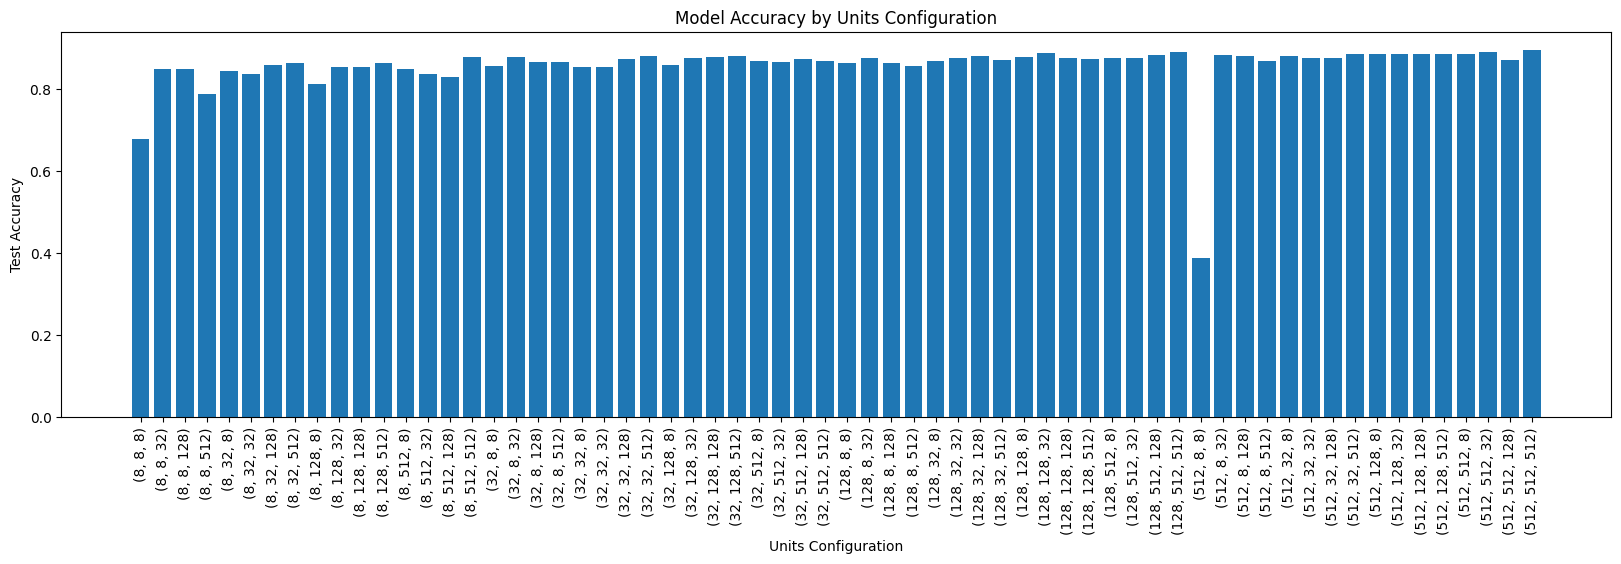

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5))

keys = list(results.keys())
values = list(results.values())

# Convert tuples to strings for plotting
keys_str = [str(key) for key in keys]

# Create a bar chart
plt.bar(keys_str, values)

# Add labels and title
plt.xlabel("Units Configuration")
plt.ylabel("Test Accuracy")
plt.title("Model Accuracy by Units Configuration")

plt.xticks(rotation=90)

# Display the plot
plt.show()